In [ ]:


import time
import tracemalloc
import random
import math

def count_conflicts(board, n):
    """Count total attacking queen pairs."""
    conflicts = 0
    row_count = {}
    diag1     = {}
    diag2     = {}
    for col in range(n):
        row = board[col]
        d1  = row - col
        d2  = row + col
        conflicts += row_count.get(row, 0)
        conflicts += diag1.get(d1, 0)
        conflicts += diag2.get(d2, 0)
        row_count[row] = row_count.get(row, 0) + 1
        diag1[d1]      = diag1.get(d1, 0)      + 1
        diag2[d2]      = diag2.get(d2, 0)      + 1
    return conflicts


def simulated_annealing_run(n, temp, cooling_rate, max_iter):
    """
    One full SA run from a random board.
    Returns (board, iterations, solved).
    """
    # Start with a PERMUTATION board — no row conflicts from the start!
    board = list(range(n))
    random.shuffle(board)

    current_conflicts = count_conflicts(board, n)

    for iteration in range(max_iter):
        if current_conflicts == 0:
            return board, iteration, True

        # Cool temperature
        temp *= cooling_rate
        if temp < 0.001:
            break

        # Swap two random columns
        c1 = random.randint(0, n - 1)
        c2 = random.randint(0, n - 1)
        while c2 == c1:
            c2 = random.randint(0, n - 1)

        board[c1], board[c2] = board[c2], board[c1]
        new_conflicts = count_conflicts(board, n)
        delta = new_conflicts - current_conflicts

        if delta <= 0:
            current_conflicts = new_conflicts
        else:
            if random.random() < math.exp(-delta / max(temp, 0.001)):
                current_conflicts = new_conflicts
            else:
                board[c1], board[c2] = board[c2], board[c1]

    solved = current_conflicts == 0
    return (board if solved else None), max_iter, solved

def solve_nqueens_sa(n, time_limit=120):
    """Solve N-Queens with SA + automatic restarts."""

    if n <= 10:
        temp = 5.0;    cooling = 0.999;    max_iter = 5000
    elif n <= 30:
        temp = 10.0;   cooling = 0.9995;   max_iter = 20000
    elif n <= 50:
        temp = 20.0;   cooling = 0.9995;   max_iter = 50000
    elif n <= 100:
        temp = 30.0;   cooling = 0.9998;   max_iter = 100000
    elif n <= 200:
        temp = 50.0;   cooling = 0.9999;   max_iter = 300000
    else:
        temp = 80.0;   cooling = 0.99995;  max_iter = 1000000

    total_iters = 0
    restarts    = 0

    tracemalloc.start()
    start = time.perf_counter()

    while True:
        if time.perf_counter() - start >= time_limit:
            break

        board, iters, solved = simulated_annealing_run(n, temp, cooling, max_iter)
        total_iters += iters
        restarts    += 1

        if solved:
            elapsed = time.perf_counter() - start
            _, peak = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            return board, elapsed, peak / 1024, total_iters, restarts, True

    elapsed = time.perf_counter() - start
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return None, elapsed, peak / 1024, total_iters, restarts, False

def validate_solution(board, n):
    if board is None:
        return False
    for i in range(n):
        for j in range(i + 1, n):
            if board[i] == board[j]:
                return False
            if abs(board[i] - board[j]) == abs(i - j):
                return False
    return True

def print_board(board, n):
    border = "  +" + "---+" * n
    print(border)
    for row in range(n):
        line = "  |"
        for col in range(n):
            line += " Q |" if board[col] == row else " . |"
        print(line)
        print(border)

def run_experiments():

    test_sizes = [10, 30, 50, 100, 200, 500]
    TIME_LIMIT = 120

    random.seed(42)

    print("=" * 82)
    print("  N-Queens — Simulated Annealing (Fixed)")
    print("=" * 82)
    print(f"  Time limit per N: {TIME_LIMIT}s")
    print("=" * 82)
    print(f"{'N':>6} | {'Time (s)':>10} | {'Mem (KB)':>10} | "
          f"{'Iterations':>12} | {'Restarts':>9} | {'Result':>7}")
    print("-" * 82)

    results = []

    for n in test_sizes:
        print(f"  Solving N={n} ...", end="", flush=True)

        board, elapsed, mem_kb, iters, restarts, found = solve_nqueens_sa(n, TIME_LIMIT)

        valid  = validate_solution(board, n)
        status = "YES" if valid else ("TIMEOUT" if not found else "ERROR")

        print(f"\r{n:>6} | {elapsed:>10.4f} | {mem_kb:>10.4f} | "
              f"{iters:>12,} | {restarts:>9,} | {status:>7}")

        if status == "TIMEOUT":
            print(f"         >> Timed out after {TIME_LIMIT}s for N={n}.")

        results.append((n, elapsed, mem_kb, iters, restarts, status))

        if n == 10 and valid:
            print(f"\n  Solution for N=10: {board}")
            print_board(board, n)
            print()

    print("\n" + "=" * 82)
    print("  FINAL SUMMARY")
    print("=" * 82)
    print(f"{'N':>6} | {'Time (s)':>10} | {'Mem (KB)':>10} | "
          f"{'Iterations':>12} | {'Restarts':>9} | {'Result':>7}")
    print("-" * 82)
    for n, t, m, it, rs, st in results:
        print(f"{n:>6} | {t:>10.4f} | {m:>10.4f} | "
              f"{it:>12,} | {rs:>9,} | {st:>7}")

    print("\n  Key observations:")
    print("  - SA escapes local minima by accepting worse moves at high temp.")
    print("  - Starting with a permutation removes all row conflicts instantly.")
    print("  - Much faster than DFS and more reliable than Hill Climbing.")
    print("=" * 82)

    return results


if __name__ == "__main__":
    run_experiments()

  N-Queens — Simulated Annealing (Fixed)
  Time limit per N: 120s
     N |   Time (s) |   Mem (KB) |   Iterations |  Restarts |  Result
----------------------------------------------------------------------------------
    10 |     0.0074 |     1.3047 |          506 |         1 |     YES

  Solution for N=10: [5, 1, 8, 0, 7, 4, 2, 9, 6, 3]
  +---+---+---+---+---+---+---+---+---+---+
  | . | . | . | Q | . | . | . | . | . | . |
  +---+---+---+---+---+---+---+---+---+---+
  | . | Q | . | . | . | . | . | . | . | . |
  +---+---+---+---+---+---+---+---+---+---+
  | . | . | . | . | . | . | Q | . | . | . |
  +---+---+---+---+---+---+---+---+---+---+
  | . | . | . | . | . | . | . | . | . | Q |
  +---+---+---+---+---+---+---+---+---+---+
  | . | . | . | . | . | Q | . | . | . | . |
  +---+---+---+---+---+---+---+---+---+---+
  | Q | . | . | . | . | . | . | . | . | . |
  +---+---+---+---+---+---+---+---+---+---+
  | . | . | . | . | . | . | . | . | Q | . |
  +---+---+---+---+---+---+---+---+---+---

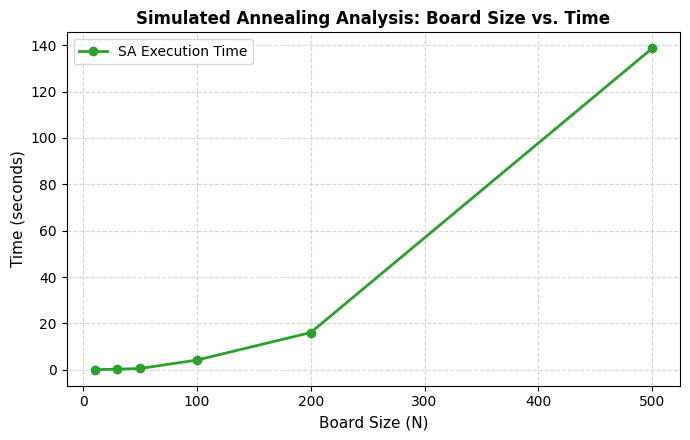

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

# Your Simulated Annealing data points
N = [10, 30, 50, 100, 200, 500]
time_taken = [0.0074, 0.2160, 0.5175, 4.1494, 16.0319, 138.6754]

# Configure the plot layout
plt.figure(figsize=(7, 4.5))
plt.plot(N, time_taken, marker='o', color='#2ca02c', linestyle='-', linewidth=2, label='SA Execution Time')

# Style modifications
plt.xlabel('Board Size (N)', fontsize=11)
plt.ylabel('Time (seconds)', fontsize=11)
plt.title('Simulated Annealing Analysis: Board Size vs. Time', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

# Save as vector PDF and download
pdf_filename = 'sa_time_complexity.pdf'
plt.savefig(pdf_filename, format='pdf', dpi=300)
plt.show()

files.download(pdf_filename)